# 16 - Can a New Data Modality Move the 0.78 Ceiling? (CBA process data)

Notebooks 11-15 argue the ~0.78 ceiling is a property of the *data*, not the feature set - but every feature so far comes from the same questionnaire modality. This notebook links a genuinely **new data source** the project has never used: PISA's computer-based-assessment **process data** (`scripts/run_process_modality.py`), joined 1:1 to the student file by `CNTSTUID`:

* **cognitive process** (2022 `STU_COG`, 2018 `STU_TTM`) - per-item response *time* and *visit* counts across 443 timed items;
* **questionnaire timing** (2022 `STU_TIM`) - response latency per background-question screen.

**Leakage discipline:** item *correctness* mechanically determines the plausible-value target, so it is never used. Only *behavioural* features enter - how long a student spent and how they navigated, not whether they were right (see `src/features/process.py`).

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
abl = pd.read_csv('../outputs/results/process_modality_ablation.csv')
imp = pd.read_csv('../outputs/results/process_feature_importance_2022.csv', index_col=0)
abl

,cycle,baseline,modality,base_auc,process_auc,lift,lift_p,n,n_proc_feats
0,2022,student,cognitive+questionnaire,0.7139,0.8473,0.1334,0.000,6129,15
1,2022,student+school,cognitive+questionnaire,0.7728,0.8579,0.0851,0.000,6129,15
2,2022,student+school,cognitive-only,0.7728,0.8508,0.0780,0.000,6129,10
3,2022,student+school,questionnaire-only,0.7728,0.7842,0.0114,0.019,6129,5
4,2018,student,cognitive+questionnaire,0.6764,0.7649,0.0885,0.000,6359,10
5,2018,student+school,cognitive+questionnaire,0.6957,0.7728,0.0771,0.000,6359,10


## 1. The ceiling moves - a new modality lifts AUC where features could not

Weighted 5x2 CV AUC, student and student+school baselines, +process features (Nadeau-Bengio corrected test).

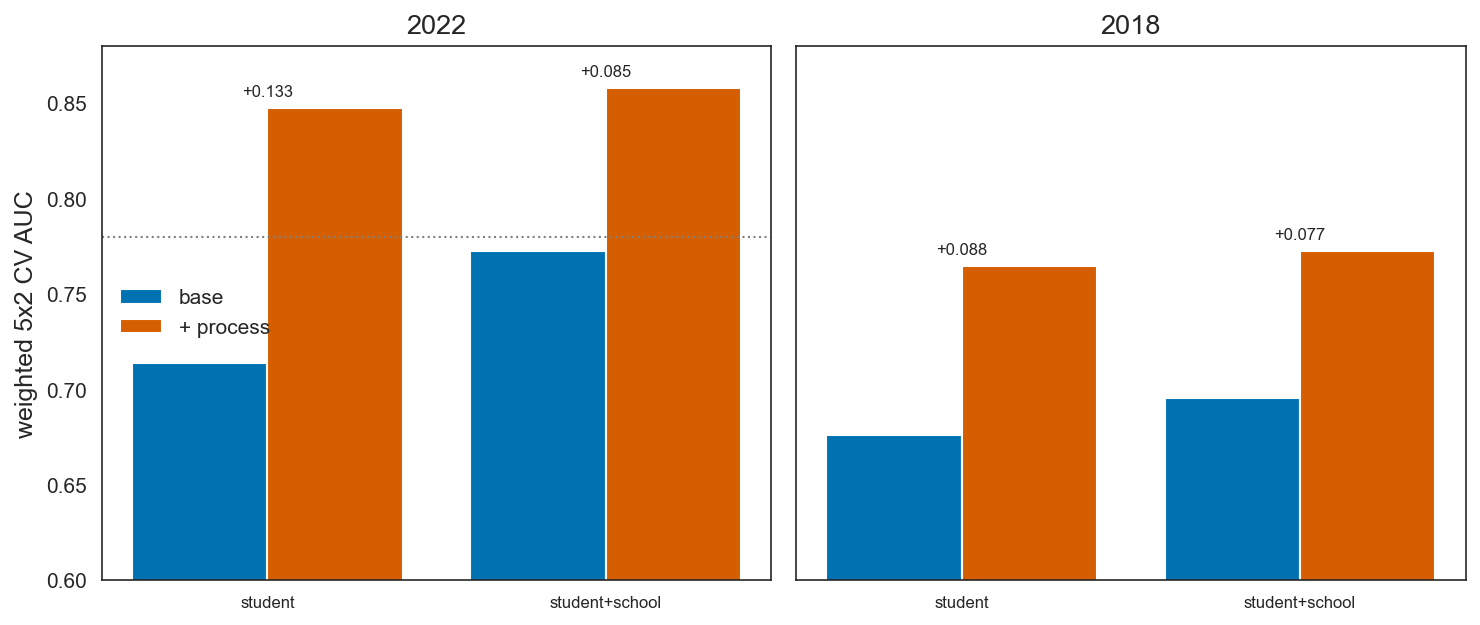

In [3]:
comb = abl[abl.modality=='cognitive+questionnaire']
fig, axes = plt.subplots(1,2, figsize=(10,4.3), sharey=True)
for ax, cyc in zip(axes,(2022,2018)):
    t = comb[comb.cycle==cyc]; x=np.arange(len(t))
    ax.bar(x-0.2, t.base_auc, 0.4, label='base', color=PALETTE['blue'])
    ax.bar(x+0.2, t.process_auc, 0.4, label='+ process', color=PALETTE['vermilion'])
    for i,r in enumerate(t.itertuples()):
        ax.text(i, max(r.base_auc,r.process_auc)+0.006, f'{r.lift:+.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(t.baseline, fontsize=8); ax.set_title(str(cyc)); ax.set_ylim(0.6,0.88)
    if cyc==2022: ax.axhline(0.78, ls=':', color='0.5', lw=1)
axes[0].set_ylabel('weighted 5x2 CV AUC'); axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Reading:** adding process features lifts the AUC at every baseline. At the headline student+school ceiling the 2022 AUC rises **0.773 -> 0.858 (+8.5 pp, p < 0.001)**, and 0.696 -> 0.773 in 2018. So the ceiling that a decade of questionnaire features could not break is *not* an absolute limit - a different data modality carries real extra signal. The next section asks whether that signal is one we could ever actually screen with.

## 2. Decomposition: is the lift deployable, or an artefact of taking the test?

The lift splits into two very different modalities. Cognitive process is measured *from the math test itself* - it is endogenous to the ability being predicted and only exists *after* a student sits the CBA. Questionnaire timing is a separate instrument, available without the cognitive test.

In [4]:
dec = abl[(abl.cycle==2022)&(abl.baseline=='student+school')]
dec[['modality','base_auc','process_auc','lift','lift_p','n_proc_feats']].round(4)

,modality,base_auc,process_auc,lift,lift_p,n_proc_feats
1,cognitive+questionnaire,0.7728,0.8579,0.0851,0.000,15
2,cognitive-only,0.7728,0.8508,0.0780,0.000,10
3,questionnaire-only,0.7728,0.7842,0.0114,0.019,5


**Reading:** the +8.5 pp is almost entirely **cognitive process** (+7.8 pp on its own). The **questionnaire-timing** modality - the only slice usable *before* the test, i.e. the only one a real screener could deploy - adds just **+1.1 pp** (p = 0.019). So a new modality moves the *number*, but the movement is post-hoc process data that (a) is endogenous to proficiency and (b) cannot flag a student early. The **deployable screening ceiling essentially holds at ~0.78**.

## 3. What the model uses: pure timing

LightGBM importance over the process features (explanatory fit, 2022 student+school).

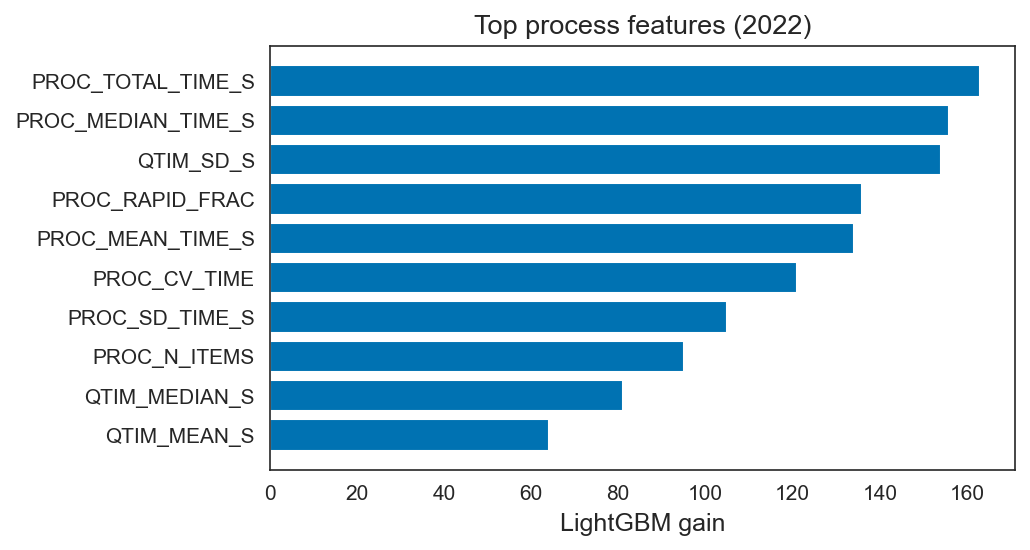

In [5]:
ip = imp[imp.index.str.startswith(('PROC_','QTIM_'))].head(10)
fig, ax = plt.subplots(figsize=(7,3.8))
ax.barh(ip.index[::-1], ip['gain'].values[::-1], color=PALETTE['blue'])
ax.set_xlabel('LightGBM gain'); ax.set_title('Top process features (2022)')
plt.tight_layout(); plt.show()

**Reading:** total and median time-on-task, rapid-response fraction and pacing variability dominate - the model reads *how* a student worked through the test. These are exactly the endogenous, post-hoc signals from section 2: informative about ability, useless as an early-warning screen.

## Conclusions & Interpretation

- **A new modality does move the ceiling** - CBA process data lifts the 2022 AUC to **0.86**, the first thing in the project to break 0.78. The ceiling is not an absolute information limit.
- **But the movement is not deployable.** ~90% of the lift is cognitive-test process data, which is endogenous to the proficiency it predicts and only observable after the assessment. It cannot screen a student in advance.
- **The screening ceiling holds.** The only pre-test modality (questionnaire response latency) adds +1.1 pp - real but marginal. For the paper's actual use case - flagging at-risk students from background data - ~0.78 stands.
- **This sharpens, not contradicts, the data-ceiling thesis.** The ceiling is about *what is knowable before the test*. Rich behavioural signal exists inside the test, but harvesting it requires administering the very assessment a screener is meant to anticipate. Reported honestly, including the large cognitive-process lift we cannot use.